In [1]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

DATA_PATH = '../tp/processed_datasets/'
X_TEST_PATH = DATA_PATH + 'X_test_catboost.parquet'
Y_TEST_PATH = DATA_PATH + 'y_test.csv'

X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet")
y_test_raw = pd.read_csv(Y_TEST_PATH).squeeze()

# Transfrom (0,1,2,3,4) to (0,1,2)

y_test  = np.clip(y_test_raw, 0, 2)

categorical_features = X_test.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
categorical_features.extend(['DAY_OF_WEEK'])
print(f"Detected {len(categorical_features)} categorical features.")

Detected 11 categorical features.


### Comparacion

In [3]:
model_normal = CatBoostClassifier().load_model("catboost_012.cbm")
model_smote = CatBoostClassifier().load_model("catboost_012_smote.cbm")
model_drop = CatBoostClassifier().load_model("catboost_012_drop.cbm")

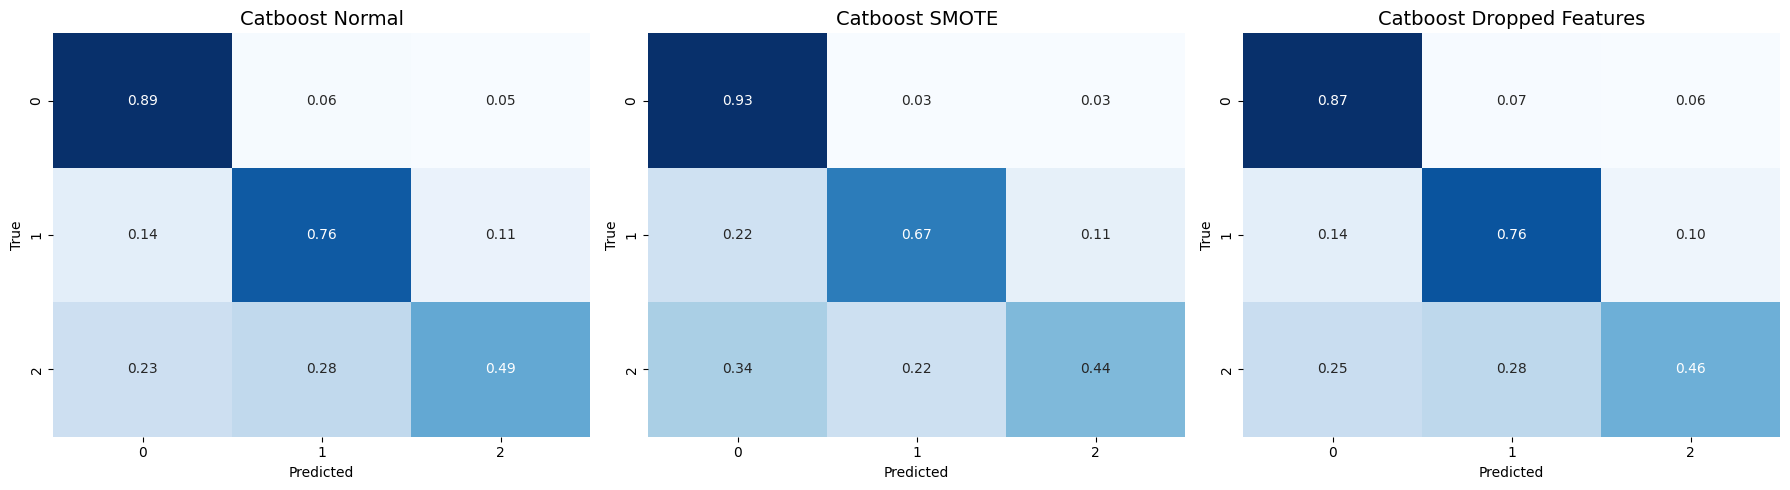

In [18]:
y_pred_normal = model_normal.predict(X_test)
y_pred_smote = model_smote.predict(X_test)
y_pred_drop = model_drop.predict(X_test.drop(columns=['WFO', 'SOURCE']))

cm_normal = confusion_matrix(y_test, y_pred_normal,normalize='true')
cm_smote = confusion_matrix(y_test, y_pred_smote,normalize='true')
cm_drop = confusion_matrix(y_test, y_pred_drop,normalize='true')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmap = "Blues"

sns.heatmap(cm_normal, annot=True, fmt='.2f', cmap=cmap, cbar=False, ax=axes[0])
axes[0].set_title('Catboost Normal', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_smote, annot=True, fmt='.2f', cmap=cmap, cbar=False, ax=axes[1])
axes[1].set_title('Catboost SMOTE', fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

sns.heatmap(cm_drop, annot=True, fmt='.2f', cmap=cmap, cbar=False, ax=axes[2]) 
axes[2].set_title('Catboost Dropped Features', fontsize=14)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.show()

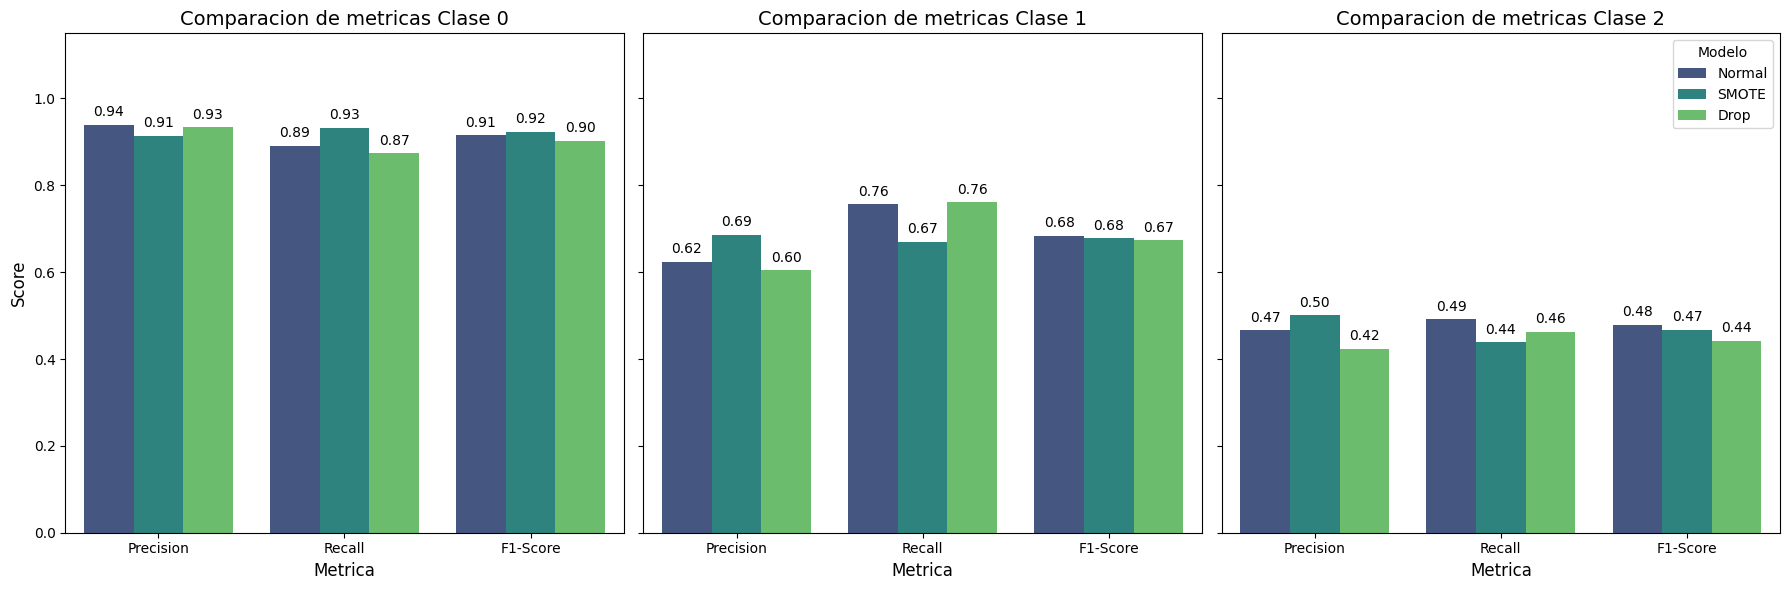

In [22]:
report_normal = classification_report(y_test, y_pred_normal, output_dict=True)
report_smote = classification_report(y_test, y_pred_smote, output_dict=True)
report_drop = classification_report(y_test, y_pred_drop, output_dict=True)

classes_to_plot = ['0', '1', '2']

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, target_class in enumerate(classes_to_plot):
    # 1. Extract data for the current class
    data = [
        {'Model': 'Normal', 
         'Precision': report_normal[target_class]['precision'],
         'Recall': report_normal[target_class]['recall'],
         'F1-Score': report_normal[target_class]['f1-score']},
        
        {'Model': 'SMOTE', 
         'Precision': report_smote[target_class]['precision'],
         'Recall': report_smote[target_class]['recall'],
         'F1-Score': report_smote[target_class]['f1-score']},
        
        {'Model': 'Drop', 
         'Precision': report_drop[target_class]['precision'],
         'Recall': report_drop[target_class]['recall'],
         'F1-Score': report_drop[target_class]['f1-score']}
    ]
    
    # 2. Convert to DataFrame and reshape
    df_metrics = pd.DataFrame(data)
    df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
    
    # 3. Plot on the specific axis (axes[i])
    sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis', ax=axes[i])
    
    # 4. Formatting for each subplot
    axes[i].set_ylim(0, 1.15) # Leave a bit more room at the top for labels
    axes[i].set_title(f'Comparacion de metricas Clase {target_class}', fontsize=14)
    axes[i].set_xlabel('Metrica', fontsize=12)
    
    # Only show the Y-axis label on the first plot to keep it clean
    if i == 0:
        axes[i].set_ylabel('Score', fontsize=12)
    else:
        axes[i].set_ylabel('')
        
    # Keep the legend only on the last plot so it doesn't repeat 3 times
    if i < 2:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Modelo', loc='upper right')

    # 5. Add the text annotations on top of the bars
    for p in axes[i].patches:
        height = p.get_height()
        # Ensure we only annotate bars that have a height (avoiding NaN errors)
        if height > 0: 
            axes[i].annotate(f"{height:.2f}", 
                             (p.get_x() + p.get_width() / 2., height), 
                             ha='center', va='center', 
                             xytext=(0, 9), 
                             textcoords='offset points',
                             fontsize=10)

# Adjust layout to prevent overlap and display
plt.tight_layout()
plt.show()

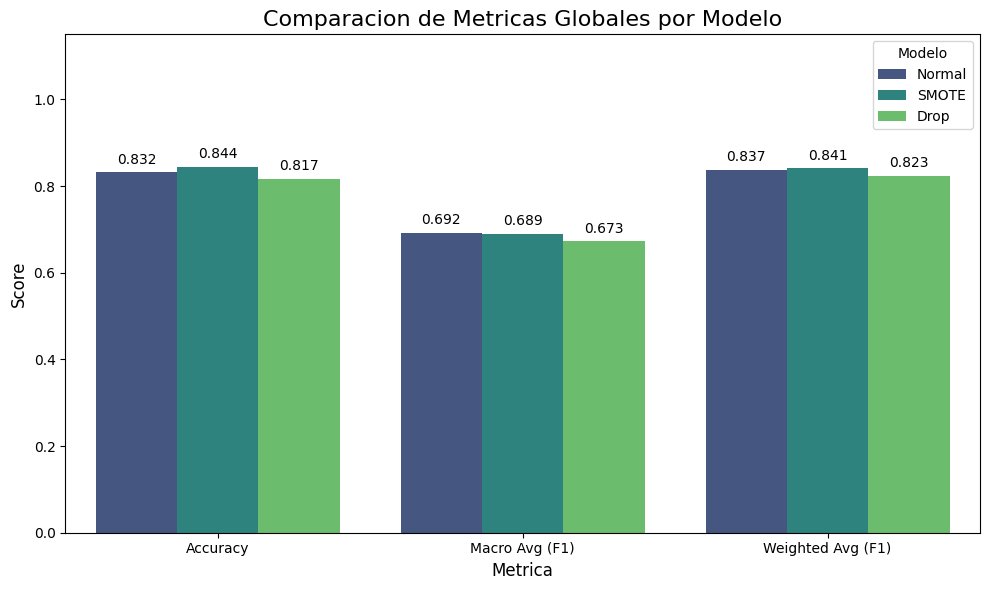

In [21]:
data = [
    {'Model': 'Normal', 
     'Accuracy': report_normal['accuracy'],
     'Macro Avg (F1)': report_normal['macro avg']['f1-score'],
     'Weighted Avg (F1)': report_normal['weighted avg']['f1-score']},
    
    {'Model': 'SMOTE', 
     'Accuracy': report_smote['accuracy'],
     'Macro Avg (F1)': report_smote['macro avg']['f1-score'],
     'Weighted Avg (F1)': report_smote['weighted avg']['f1-score']},
    
    {'Model': 'Drop', 
     'Accuracy': report_drop['accuracy'],
     'Macro Avg (F1)': report_drop['macro avg']['f1-score'],
     'Weighted Avg (F1)': report_drop['weighted avg']['f1-score']}
]

# 2. Convert to DataFrame and reshape for Seaborn
df_overall = pd.DataFrame(data)
df_melted = df_overall.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 3. Plot the grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')

# 4. Formatting the graph
plt.ylim(0, 1.15) # Give space for the legend and annotations
plt.title('Comparacion de Metricas Globales por Modelo', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrica', fontsize=12)
plt.legend(title='Modelo', loc='upper right')

# 5. Add the exact numbers on top of the bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0: # Check to avoid annotating missing data
        plt.gca().annotate(f"{height:.3f}", # Using 3 decimal places for overall metrics
                           (p.get_x() + p.get_width() / 2., height), 
                           ha='center', va='center', 
                           xytext=(0, 9), 
                           textcoords='offset points',
                           fontsize=10)

plt.tight_layout()
plt.show()